# Tremor Pipeline Section 1: Data Inspection

Goal: load the two pickles and inspect everything before writing a single line of feature code.

- Structure of each `imu_sdata[subject_id]` entry, indices `[0]`..`[3]`
- What index `[2]` actually contains (context doc says "unknown")
- Metadata top-level keys + `med_eval_1` / `med_eval_2` full contents
- Coverage + distribution of `tremor_manual_2_2_2020_new`
- Session / window distributions and anything that looks odd

In [39]:
import pickle
import numpy as np
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)

## 1.1 Load pickles and basic counts

In [40]:
with open('imu_sdata.pickle', 'rb') as f:
    imu_sdata = pickle.load(f)
with open('subject_metadata.pickle', 'rb') as f:
    metadata = pickle.load(f)

print(f'imu_sdata        : type={type(imu_sdata).__name__}, len={len(imu_sdata)}')
print(f'subject_metadata : type={type(metadata).__name__}, len={len(metadata)}')

subject_ids = list(imu_sdata.keys())
print(f'\nFirst 5 IMU subject IDs: {subject_ids[:5]}')

# metadata is keyed by the same subject IDs (plus many more subjects without IMU data)
meta_lookup = {sid: metadata[sid] for sid in subject_ids if sid in metadata}
print(f'\nMetadata lookup built for {len(meta_lookup)} of {len(subject_ids)} IMU subjects')
print(f'Total entries in subject_metadata pickle: {len(metadata)}  (includes subjects without IMU data)')

imu_sdata        : type=dict, len=81
subject_metadata : type=dict, len=1716

First 5 IMU subject IDs: ['f1b42729314b6f9b', 'ac6a73f3422c2c23', 'bcb2a210329fee87', '418d8c4cb78b2514', 'a44f913146fa5f87']

Metadata lookup built for 81 of 81 IMU subjects
Total entries in subject_metadata pickle: 1716  (includes subjects without IMU data)


In [41]:
# Health status split
health_counts = Counter()
for sid in subject_ids:
    h = meta_lookup.get(sid, {}).get('healthstatus_id', 'MISSING')
    health_counts[h] += 1

print('healthstatus_id distribution across the 81 IMU subjects:')
for k, v in sorted(health_counts.items(), key=lambda kv: (kv[0] is None, kv[0])):
    lab = {0: 'PD', 1: 'Healthy + family hx', 2: 'Healthy'}.get(k, str(k))
    print(f'  {k} ({lab}): {v}')

pd_subjects = [sid for sid in subject_ids if meta_lookup.get(sid, {}).get('healthstatus_id') == 0]
hc_subjects = [sid for sid in subject_ids if meta_lookup.get(sid, {}).get('healthstatus_id') in (1, 2)]
print(f'\nPD subjects: {len(pd_subjects)}  |  HC subjects: {len(hc_subjects)}')

healthstatus_id distribution across the 81 IMU subjects:
  0 (PD): 49
  1 (Healthy + family hx): 13
  2 (Healthy): 19

PD subjects: 49  |  HC subjects: 32


## 1.2  IMU entry structure: `imu_sdata[subject_id]` indices [0]..[3]

Context doc claims:  
- `[0]` = frequency-domain pre-FFT'd  
- `[1]` = per-subject UPDRS dict  
- `[2]` = unknown  
- `[3]` = raw time-domain â€” **what we use**

We verify against one PD subject and one HC subject.

In [42]:
def describe(obj, prefix='  '):
    t = type(obj).__name__
    if isinstance(obj, np.ndarray):
        print(f'{prefix}type=ndarray, shape={obj.shape}, dtype={obj.dtype}')
    elif isinstance(obj, dict):
        print(f'{prefix}type=dict, n_keys={len(obj)}, keys={list(obj.keys())}')
    elif isinstance(obj, (list, tuple)):
        print(f'{prefix}type={t}, len={len(obj)}')
        if len(obj) > 0:
            print(f'{prefix}  first element:')
            describe(obj[0], prefix + '    ')
    elif obj is None:
        print(f'{prefix}type=None')
    else:
        print(f'{prefix}type={t}, value={obj!r}')


def inspect_entry(sid, label):
    entry = imu_sdata[sid]
    print(f'\n===== {label} â€” subject {sid} =====')
    print(f'Entry type: {type(entry).__name__}, len={len(entry)}')
    for i in range(len(entry)):
        print(f'\n[{i}]:')
        describe(entry[i])


inspect_entry(pd_subjects[0], 'PD')
inspect_entry(hc_subjects[0], 'HC')


===== PD â€” subject f1b42729314b6f9b =====
Entry type: tuple, len=4

[0]:
  type=list, len=385
    first element:
      type=ndarray, shape=(3, 76, 3), dtype=float64

[1]:
  type=dict, n_keys=8, keys=['updrs16', 'updrs20_right', 'updrs20_left', 'updrs21_right', 'updrs21_left', 'fpp_ams_tremor', 'fpp_ams_tremor_sev', 'tremor_manual']

[2]:
  type=list, len=385
    first element:
      type=str, value='ce2f382c41b814fe9cfd6f0c3ed402a9'

[3]:
  type=list, len=385
    first element:
      type=ndarray, shape=(3, 500, 3), dtype=float64

===== HC â€” subject bcb2a210329fee87 =====
Entry type: tuple, len=4

[0]:
  type=list, len=134
    first element:
      type=ndarray, shape=(11, 76, 3), dtype=float64

[1]:
  type=dict, n_keys=8, keys=['updrs16', 'updrs20_right', 'updrs20_left', 'updrs21_right', 'updrs21_left', 'fpp_ams_tremor', 'fpp_ams_tremor_sev', 'tremor_manual']

[2]:
  type=list, len=134
    first element:
      type=str, value='48d67d0ad4fd00cb157860fbde2a200f'

[3]:
  type=list, l

In [43]:
# Dig into index [2] context doc says "unknown"
pd_entry = imu_sdata[pd_subjects[0]]
idx2 = pd_entry[2]
print(f'Index [2] for PD subject {pd_subjects[0]}:')
print(f'  type : {type(idx2).__name__}')
print(f'  len  : {len(idx2)}')
print(f'  first 5 elements:')
for v in idx2[:5]:
    print(f'    {type(v).__name__}  len={len(str(v))}  value={v!r}')

# Are they hex strings? All same length?
lens = {len(x) for x in idx2}
is_hex = all(all(c in '0123456789abcdef' for c in x) for x in idx2[:20])
print(f'\n  length set: {lens}  |  first 20 all hex chars? {is_hex}')
print(f'  unique IDs in [2]: {len(set(idx2))}  (vs len={len(idx2)})')

# Are lengths of [0], [2], [3] all equal (one entry per phone call)?
print('\n--- Length comparison across [0], [2], [3] for first 8 subjects ---')
print(f'{"subject":22s}  [0]   [2]   [3]   match')
for sid in subject_ids[:8]:
    e = imu_sdata[sid]
    l0, l2, l3 = len(e[0]), len(e[2]), len(e[3])
    print(f'{sid:22s}  {l0:4d}  {l2:4d}  {l3:4d}  {l0 == l2 == l3}')

Index [2] for PD subject f1b42729314b6f9b:
  type : list
  len  : 385
  first 5 elements:
    str  len=32  value='ce2f382c41b814fe9cfd6f0c3ed402a9'
    str  len=32  value='ceef0b4ebf606010a7bdd25c4e822216'
    str  len=32  value='20e737c82cd3b87282a2f690a9cac7a0'
    str  len=32  value='c711edbd7dd4b2c3b9a0d226aca46db9'
    str  len=32  value='309aed1bff8e3c29f04bb27b23291c5c'

  length set: {32}  |  first 20 all hex chars? True
  unique IDs in [2]: 385  (vs len=385)

--- Length comparison across [0], [2], [3] for first 8 subjects ---
subject                 [0]   [2]   [3]   match
f1b42729314b6f9b         385   385   385  True
ac6a73f3422c2c23          10    10    10  True
bcb2a210329fee87         134   134   134  True
418d8c4cb78b2514          15    15    15  True
a44f913146fa5f87          34    34    34  True
6cc41389d3e9aea9         127   127   127  True
7a34167938cb1d9a          36    36    36  True
f78737822482c8e4           4     4     4  True


## 1.3  Metadata: top-level keys and full `med_eval_1`, `med_eval_2`

In [44]:
pd_sid = pd_subjects[0]
pd_meta = meta_lookup[pd_sid]
print(f'Subject: {pd_sid}')
print(f'Top-level metadata keys: {list(pd_meta.keys())}')
print(f'\nDemographics:')
for k in ['serial', 'age', 'gender_id', 'education_id', 'healthstatus_id',
         'usability_id', 'languagecode', 'iscontacted', 'isactive', 'study_id']:
    if k in pd_meta:
        print(f'  {k}: {pd_meta[k]!r}')

for ek in ('med_eval_1', 'med_eval_2'):
    print(f'\n--- {ek} ---')
    val = pd_meta.get(ek)
    if not isinstance(val, dict):
        print(f'  (not a dict: {type(val).__name__})')
        continue
    print(f'  keys ({len(val)}):')
    for k, v in val.items():
        print(f'    {k!r:40s} = {v!r}')

Subject: f1b42729314b6f9b
Top-level metadata keys: ['serial', 'age', 'gender_id', 'education_id', 'healthstatus_id', 'usability_id', 'languagecode', 'iscontacted', 'isactive', 'study_id', 'med_eval_1', 'med_eval_2']

Demographics:
  serial: 'f1b42729314b6f9b'
  age: 1951
  gender_id: 0
  education_id: 0
  healthstatus_id: 0
  usability_id: 2
  languagecode: 'en'
  iscontacted: True
  isactive: True
  study_id: 'SUK03'

--- med_eval_1 ---
  keys (55):
    'date'                                   = datetime.datetime(2018, 5, 4, 0, 0)
    'pd_start_year'                          = 2014.0
    'pd_status'                              = 1.0
    'updrs_18'                               = 0
    'updrs_19'                               = 1
    'updrs_20_flc'                           = 0
    'updrs_20_hand_right'                    = 0
    'updrs_20_hand_left'                     = 3
    'updrs_20_foot_right'                    = 1
    'updrs_20_foot_left'                     = 2
    'updrs_21_

In [45]:
# UPDRS tremor label coverage
TREMOR_KEY = 'tremor_manual_2_2_2020_new'

has_eval1 = [sid for sid in subject_ids if isinstance(meta_lookup.get(sid, {}).get('med_eval_1'), dict)]
has_eval2 = [sid for sid in subject_ids if isinstance(meta_lookup.get(sid, {}).get('med_eval_2'), dict)]
print(f'Subjects with med_eval_1 (dict): {len(has_eval1)} / {len(subject_ids)}')
print(f'Subjects with med_eval_2 (dict): {len(has_eval2)} / {len(subject_ids)}')

label_records = []
for sid in subject_ids:
    me1 = meta_lookup.get(sid, {}).get('med_eval_1')
    if isinstance(me1, dict) and TREMOR_KEY in me1:
        label_records.append({
            'subject_id'    : sid,
            'health_status' : meta_lookup[sid].get('healthstatus_id'),
            'tremor_label'  : me1[TREMOR_KEY],
        })

df_labels = pd.DataFrame(label_records)
print(f'\nSubjects with tremor_manual_2_2_2020_new: {len(df_labels)}')
print(f'\nOverall label distribution: {dict(df_labels.tremor_label.value_counts())}')
print(f'\nBy health_status Ã— tremor_label:')
print(pd.crosstab(df_labels.health_status, df_labels.tremor_label, margins=True))

Subjects with med_eval_1 (dict): 81 / 81
Subjects with med_eval_2 (dict): 81 / 81

Subjects with tremor_manual_2_2_2020_new: 80

Overall label distribution: {0: np.int64(56), 1: np.int64(24)}

By health_status Ã— tremor_label:
tremor_label    0   1  All
health_status             
0              25  23   48
1              13   0   13
2              18   1   19
All            56  24   80


## 1.4  Session / window structure

Context doc claims each session is shape `(N_windows, 500, 3)`.  
We verify per-subject session counts, per-session window counts, total windows per subject, and any oddities.

In [46]:
rows = []
odd = []
for sid in subject_ids:
    entry = imu_sdata[sid]
    sessions = entry[3]
    health = meta_lookup.get(sid, {}).get('healthstatus_id')
    if not isinstance(sessions, list):
        odd.append((sid, 'sessions not list', type(sessions).__name__))
        continue
    total_w = 0
    for si, sess in enumerate(sessions):
        if not isinstance(sess, np.ndarray):
            odd.append((sid, si, f'non-array {type(sess).__name__}'))
            continue
        if sess.ndim != 3 or sess.shape[1:] != (500, 3):
            odd.append((sid, si, f'shape {sess.shape}'))
        n_w = sess.shape[0]
        total_w += n_w
        rows.append({'subject_id': sid, 'health_status': health,
                     'session_idx': si, 'n_windows': n_w})
    rows[-1] if rows else None

df_sess = pd.DataFrame(rows)
print(f'Total (subject, session) rows: {len(df_sess)}')
print(f'Odd entries: {len(odd)}')
if odd:
    for o in odd[:20]:
        print(f'  {o}')

subj_stats = df_sess.groupby('subject_id').agg(
    n_sessions=('session_idx', 'count'),
    total_windows=('n_windows', 'sum'),
    mean_windows_per_sess=('n_windows', 'mean'),
).reset_index()
subj_stats = subj_stats.merge(
    df_sess[['subject_id', 'health_status']].drop_duplicates(),
    on='subject_id')

print('\n--- Sessions per subject (n=81) ---')
print(subj_stats['n_sessions'].describe(percentiles=[.1, .25, .5, .75, .9]).round(1))
print('\n--- Windows per session (n={}) ---'.format(len(df_sess)))
print(df_sess['n_windows'].describe(percentiles=[.1, .25, .5, .75, .9]).round(1))
print('\n--- Total windows per subject ---')
print(subj_stats['total_windows'].describe(percentiles=[.1, .25, .5, .75, .9]).round(1))

print(f'\nTotal windows in dataset: {df_sess["n_windows"].sum()}')

Total (subject, session) rows: 8627
Odd entries: 0

--- Sessions per subject (n=81) ---
count      81.0
mean      106.5
std       233.5
min         1.0
10%         3.0
25%         7.0
50%        26.0
75%       106.0
90%       227.0
max      1753.0
Name: n_sessions, dtype: float64

--- Windows per session (n=8627) ---
count    8627.0
mean        6.6
std         2.9
min         3.0
10%         3.0
25%         4.0
50%         6.0
75%         9.0
90%        11.0
max        16.0
Name: n_windows, dtype: float64

--- Total windows per subject ---
count       81.0
mean       703.8
std       1599.8
min          4.0
10%         15.0
25%         52.0
50%        175.0
75%        670.0
90%       1462.0
max      12122.0
Name: total_windows, dtype: float64

Total windows in dataset: 57010


In [47]:
# Outliers / flags
print('Outliers / insufficient-data flags:')
print(f'  Subjects with 1 session only       : {(subj_stats.n_sessions == 1).sum()}')
print(f'  Subjects with < 5 total windows    : {(subj_stats.total_windows < 5).sum()}  (paper min_windows=5)')
print(f'  Sessions with < 3 windows          : {(df_sess.n_windows < 3).sum()}  (our insufficient flag)')
print(f'  Sessions with 3-5 windows ("low")  : {((df_sess.n_windows >= 3) & (df_sess.n_windows < 6)).sum()}')
print(f'  Sessions with >= 6 windows ("high"): {(df_sess.n_windows >= 6).sum()}')

print('\nLargest n_sessions (by subject):')
print(subj_stats.sort_values('n_sessions', ascending=False).head(10).to_string(index=False))
print('\nSmallest n_sessions (by subject):')
print(subj_stats.sort_values('n_sessions', ascending=True).head(10).to_string(index=False))

Outliers / insufficient-data flags:
  Subjects with 1 session only       : 5
  Subjects with < 5 total windows    : 1  (paper min_windows=5)
  Sessions with < 3 windows          : 0  (our insufficient flag)
  Sessions with 3-5 windows ("low")  : 3818
  Sessions with >= 6 windows ("high"): 4809

Largest n_sessions (by subject):
      subject_id  n_sessions  total_windows  mean_windows_per_sess  health_status
393ac67b9a76136f        1753          12122               6.915003              1
15d907c726d2fc44         741           5059               6.827260              0
a0433fa95436cefb         541           2649               4.896488              2
563f2d62693960d7         507           3273               6.455621              0
95f9756b35b97753         502           3461               6.894422              0
 4b3075b01e570d5         499           3883               7.781563              0
f1b42729314b6f9b         385           2836               7.366234              0
15963826e88041d

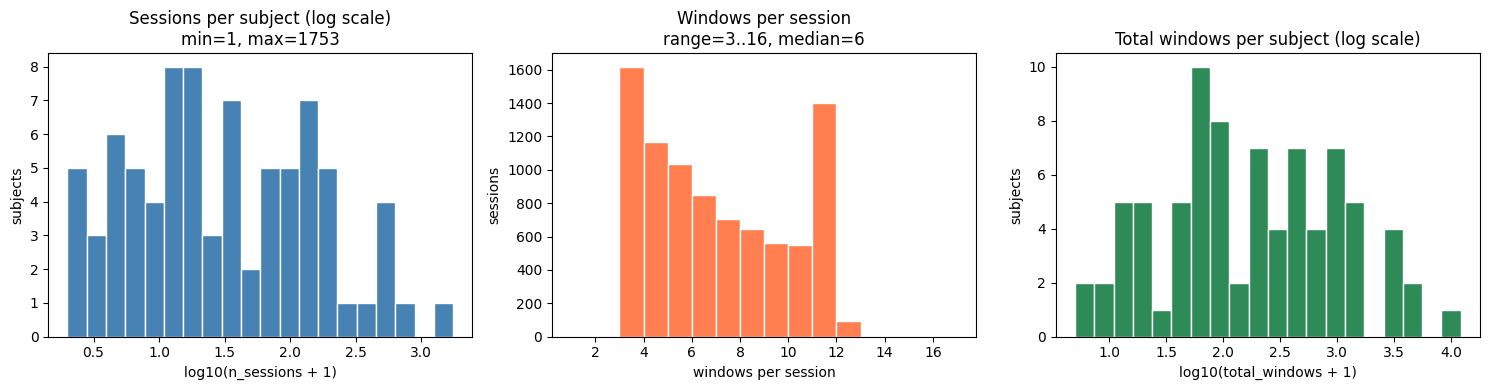

In [48]:
# Visual summary
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(np.log10(subj_stats.n_sessions + 1), bins=20, color='steelblue', edgecolor='white')
axes[0].set_xlabel('log10(n_sessions + 1)')
axes[0].set_ylabel('subjects')
axes[0].set_title(f'Sessions per subject (log scale)\nmin={subj_stats.n_sessions.min()}, max={subj_stats.n_sessions.max()}')

axes[1].hist(df_sess.n_windows, bins=range(1, df_sess.n_windows.max() + 2),
             color='coral', edgecolor='white')
axes[1].set_xlabel('windows per session')
axes[1].set_ylabel('sessions')
axes[1].set_title(f'Windows per session\nrange={df_sess.n_windows.min()}..{df_sess.n_windows.max()}, median={df_sess.n_windows.median():.0f}')

axes[2].hist(np.log10(subj_stats.total_windows + 1), bins=20, color='seagreen', edgecolor='white')
axes[2].set_xlabel('log10(total_windows + 1)')
axes[2].set_ylabel('subjects')
axes[2].set_title(f'Total windows per subject (log scale)')

plt.tight_layout()
plt.show()

In [49]:
# One raw window verify shape, range, per-axis stats
s0 = imu_sdata[pd_subjects[0]][3][0]
print(f'PD first-subject first-session array: shape={s0.shape}, dtype={s0.dtype}')
w0 = s0[0]
print(f'  First window: shape={w0.shape}')
print(f'  Per-axis mean: {w0.mean(axis=0)}')
print(f'  Per-axis std : {w0.std(axis=0)}')
print(f'  Overall min/max: {w0.min():.3f} / {w0.max():.3f}')
print(f'\n  Note: mean is near zero per axis → gravity component already small / centered.')
print(f'  Units look like g (9.81 m/s^2 ≈ 1.0 in typical phone accelerometer output).')

PD first-subject first-session array: shape=(3, 500, 3), dtype=float64
  First window: shape=(500, 3)
  Per-axis mean: [-0.0132835 -0.0155016 -0.0091666]
  Per-axis std : [0.38948553 0.27722681 0.27566199]
  Overall min/max: -1.953 / 1.333

  Note: mean is near zero per axis → gravity component already small / centered.
  Units look like g (9.81 m/s^2 ≈ 1.0 in typical phone accelerometer output).


## 2.1  Build kept_subjects (PD only, total_windows>5)

In [50]:
TREMOR_KEY = 'tremor_manual_2_2_2020_new'

exclude_subjects = {}  # sid -> reason string

for sid in imu_sdata.keys():
    health = meta_lookup.get(sid, {}).get('healthstatus_id')
    if health != 0:
        exclude_subjects[sid] = f'not PD (healthstatus_id={health})'
        continue
    total_windows = sum(imu_sdata[sid][3][s].shape[0] for s in range(len(imu_sdata[sid][3])))
    if total_windows < 5:
        exclude_subjects[sid] = f'PD but total_windows={total_windows} < 5'

kept_subjects = [sid for sid in imu_sdata.keys() if sid not in exclude_subjects]

pd_non_pd = sum(1 for r in exclude_subjects.values() if 'not PD' in r)
pd_insuf  = sum(1 for r in exclude_subjects.values() if 'total_windows' in r)
print(f'Excluded {len(exclude_subjects)} subjects:  {pd_non_pd} non-PD,  {pd_insuf} PD with <5 windows')

# Print any PD exclusions (non-PD exclusions are expected and not worth listing)
pd_excl = {sid: r for sid, r in exclude_subjects.items() if 'total_windows' in r}
if pd_excl:
    for sid, reason in pd_excl.items():
        print(f'  PD exclusion: {sid}  â†’  {reason}')
else:
    print('  No PD subjects excluded for insufficient data.')

print(f'\nkept_subjects: {len(kept_subjects)} PD subjects')

# Tremor label breakdown within kept_subjects
tpos = sum(1 for s in kept_subjects
           if isinstance(meta_lookup[s].get('med_eval_1'), dict)
           and meta_lookup[s]['med_eval_1'].get(TREMOR_KEY) == 1)
tneg = sum(1 for s in kept_subjects
           if isinstance(meta_lookup[s].get('med_eval_1'), dict)
           and meta_lookup[s]['med_eval_1'].get(TREMOR_KEY) == 0)
tunk = len(kept_subjects) - tpos - tneg
print(f'  tremor_manual=1 (PD-tremor+):  {tpos}')
print(f'  tremor_manual=0 (PD-tremor-):  {tneg}')
print(f'  label missing:                 {tunk}')

Excluded 32 subjects:  32 non-PD,  0 PD with <5 windows
  No PD subjects excluded for insufficient data.

kept_subjects: 49 PD subjects
  tremor_manual=1 (PD-tremor+):  23
  tremor_manual=0 (PD-tremor-):  25
  label missing:                 1


## 2.2  Constants and per-window feature extractor

In [51]:
from scipy import signal
from scipy.stats import entropy as scipy_entropy
from scipy.signal import butter, sosfilt

FS            = 100
WIN_SAMPLES   = 500
TREMOR_LO,  TREMOR_HI  = 4.0,  6.0
BROAD_LO,   BROAD_HI   = 3.0, 15.0
ENTROPY_LO, ENTROPY_HI = 3.0,  8.0
HP_CUTOFF     = 1.0
WELCH_NPERSEG = 256

_sos_hp = butter(4, HP_CUTOFF, 'high', fs=FS, output='sos')


def window_features(window):
    mag    = np.sqrt((window ** 2).sum(axis=1))
    mag_hp = sosfilt(_sos_hp, mag)

    freqs, psd = signal.welch(mag_hp, fs=FS, nperseg=WELCH_NPERSEG)  # Welch more stable than raw FFT for 500-sample windows

    tremor_mask  = (freqs >= TREMOR_LO)  & (freqs <= TREMOR_HI)
    broad_mask   = (freqs >= BROAD_LO)   & (freqs <= BROAD_HI)
    entropy_mask = (freqs >= ENTROPY_LO) & (freqs <= ENTROPY_HI)
    dom_mask     = (freqs >= 3.0)        & (freqs <= 7.0)

    tremor_power = np.trapezoid(psd[tremor_mask], freqs[tremor_mask])
    total_power  = np.trapezoid(psd[broad_mask],  freqs[broad_mask])
    snr          = tremor_power / (total_power + 1e-10)

    dominant_freq = freqs[dom_mask][np.argmax(psd[dom_mask])]
    in_pd_band    = float(TREMOR_LO <= dominant_freq <= TREMOR_HI)

    psd_eb   = psd[entropy_mask]
    psd_norm = psd_eb / (psd_eb.sum() + 1e-10)
    n_bins   = psd_norm.shape[0]
    spec_entropy = scipy_entropy(psd_norm + 1e-10) / np.log(n_bins)

    tremor_index = tremor_power *  (1.0 - spec_entropy)

    return {
        'tremor_power':     tremor_power,
        'dominant_freq':    dominant_freq,
        'spectral_entropy': spec_entropy,
        'snr':              snr,
        'tremor_index':     tremor_index,
        'in_pd_band':       in_pd_band,
        '_freqs':   freqs,
        '_psd':     psd,
        '_mag_hp':  mag_hp,
    }

print('Constants and window_features() defined.')

Constants and window_features() defined.


## 2.3 Sanity plot: PD-tremor+ window vs PD-tremor- window

PD-tremor+: 789dcfde8e85be2a  (tremor=1, sum_part_3=62)
PD-tremor-: d3f62806248b9cf0  (tremor=0, sum_part_3=34)


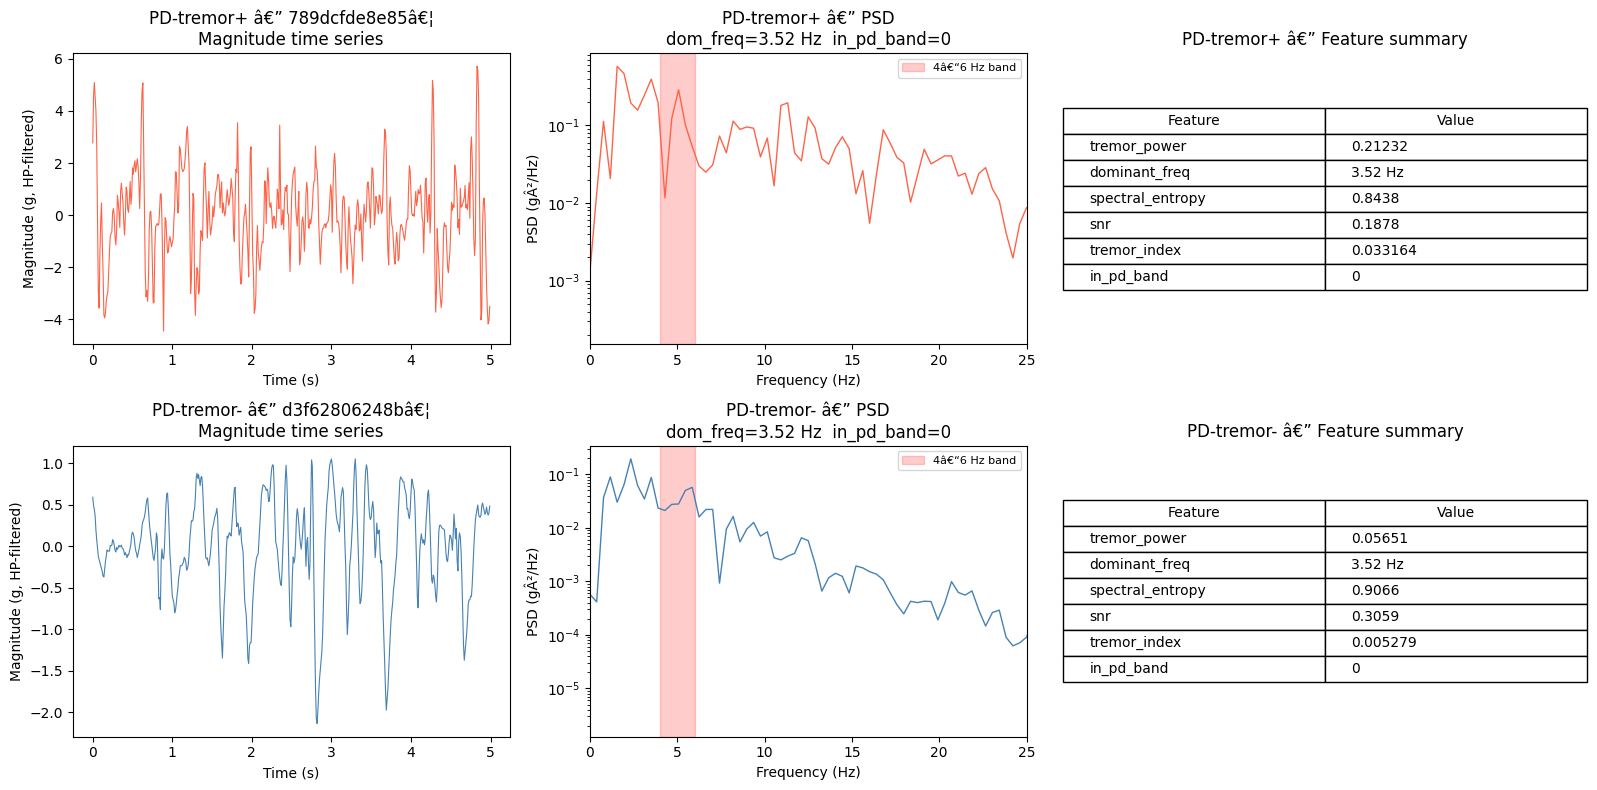


Verdict:
  PD-tremor+    dom_freq=3.52 Hz  tremor_index=0.033164  â†’ dominant freq outside 4â€“6 Hz
  PD-tremor-    dom_freq=3.52 Hz  tremor_index=0.005279  â†’ dominant freq outside 4â€“6 Hz


In [52]:
# PD-tremor+: highest sum_part_3 among tremor_manual=1 subjects
best_pos_sid, best_sum = None, -1
for sid in kept_subjects:
    me1 = meta_lookup[sid].get('med_eval_1', {})
    if not isinstance(me1, dict) or me1.get(TREMOR_KEY) != 1:
        continue
    sp3 = me1.get('sum_part_3') or 0
    if sp3 > best_sum:
        best_sum, best_pos_sid = sp3, sid

# PD-tremor-: highest sum_part_3 among tremor_manual=0 subjects
# (pick symptomatic PD-tremor- to make the contrast meaningful)
best_neg_sid, best_neg_sum = None, -1
for sid in kept_subjects:
    me1 = meta_lookup[sid].get('med_eval_1', {})
    if not isinstance(me1, dict) or me1.get(TREMOR_KEY) != 0:
        continue
    sp3 = me1.get('sum_part_3') or 0
    if sp3 > best_neg_sum:
        best_neg_sum, best_neg_sid = sp3, sid

print(f'PD-tremor+: {best_pos_sid}  (tremor=1, sum_part_3={best_sum})')
print(f'PD-tremor-: {best_neg_sid}  (tremor=0, sum_part_3={best_neg_sum})')

pos_window = imu_sdata[best_pos_sid][3][0][0]
neg_window = imu_sdata[best_neg_sid][3][0][0]

pos_feats = window_features(pos_window)
neg_feats = window_features(neg_window)

t = np.arange(WIN_SAMPLES) / FS
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
pairs = [('PD-tremor+', pos_window, pos_feats, best_pos_sid),
         ('PD-tremor-', neg_window, neg_feats, best_neg_sid)]

for row, (label, raw, feats, sid) in enumerate(pairs):
    freqs, psd = feats['_freqs'], feats['_psd']
    color = 'tomato' if 'tremor+' in label else 'steelblue'

    axes[row, 0].plot(t, feats['_mag_hp'], lw=0.8, color=color)
    axes[row, 0].set_xlabel('Time (s)')
    axes[row, 0].set_ylabel('Magnitude (g, HP-filtered)')
    axes[row, 0].set_title(f'{label} â€” {sid[:12]}â€¦\nMagnitude time series')

    axes[row, 1].semilogy(freqs, psd, lw=1.0, color=color)
    axes[row, 1].axvspan(TREMOR_LO, TREMOR_HI, alpha=0.2, color='red', label='4â€“6 Hz band')
    axes[row, 1].set_xlabel('Frequency (Hz)')
    axes[row, 1].set_ylabel('PSD (gÂ²/Hz)')
    axes[row, 1].set_xlim(0, 25)
    axes[row, 1].set_title(f'{label} â€” PSD\ndom_freq={feats["dominant_freq"]:.2f} Hz  '
                           f'in_pd_band={int(feats["in_pd_band"])}')
    axes[row, 1].legend(fontsize=8)

    axes[row, 2].axis('off')
    tbl_data = [
        ['tremor_power',     f'{feats["tremor_power"]:.5f}'],
        ['dominant_freq',    f'{feats["dominant_freq"]:.2f} Hz'],
        ['spectral_entropy', f'{feats["spectral_entropy"]:.4f}'],
        ['snr',              f'{feats["snr"]:.4f}'],
        ['tremor_index',     f'{feats["tremor_index"]:.6f}'],
        ['in_pd_band',       str(int(feats["in_pd_band"]))],
    ]
    tbl = axes[row, 2].table(cellText=tbl_data, colLabels=['Feature', 'Value'],
                              loc='center', cellLoc='left')
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(10)
    tbl.scale(1.2, 1.5)
    axes[row, 2].set_title(f'{label} â€” Feature summary')

plt.tight_layout()
plt.show()

print('\nVerdict:')
for label, feats in [('PD-tremor+', pos_feats), ('PD-tremor-', neg_feats)]:
    in_b = int(feats['in_pd_band'])
    note = '4â€“6 Hz dominant' if in_b else 'dominant freq outside 4â€“6 Hz'
    print(f'  {label:12s}  dom_freq={feats["dominant_freq"]:.2f} Hz  '
          f'tremor_index={feats["tremor_index"]:.6f}  â†’ {note}')

## 2.4  Batch feature extraction (PD subjects only, ~33k windows)

In [53]:
import time

records = []
t0 = time.time()

for sid in kept_subjects:
    me1    = meta_lookup[sid].get('med_eval_1', {})
    tlabel = me1.get(TREMOR_KEY) if isinstance(me1, dict) else None

    for s_idx, sess in enumerate(imu_sdata[sid][3]):
        for w_idx in range(sess.shape[0]):
            feats = window_features(sess[w_idx])
            records.append({
                'subject_id':          sid,
                'session_idx':         s_idx,
                'window_idx':          w_idx,
                'tremor_manual_label': tlabel,
                'tremor_power':        feats['tremor_power'],
                'dominant_freq':       feats['dominant_freq'],
                'spectral_entropy':    feats['spectral_entropy'],
                'snr':                 feats['snr'],
                'tremor_index':        feats['tremor_index'],
                'in_pd_band':          feats['in_pd_band'],
            })

df_windows = pd.DataFrame(records)
elapsed = time.time() - t0

print(f'Batch done in {elapsed:.1f}s.  df_windows shape: {df_windows.shape}')
print(f'\nNulls per column:\n{df_windows.isnull().sum()}')
print(f'\nSubjects: {df_windows.subject_id.nunique()}')
print(f'\ntremor_manual_label breakdown:')
print(df_windows.groupby("tremor_manual_label")["window_idx"].count().rename("n_windows"))
print(f'  (label=NaN â†’ {df_windows["tremor_manual_label"].isna().sum()} windows from subject with missing label)')
print(f'\ntremor_index stats:')
print(df_windows['tremor_index'].describe(percentiles=[.1,.25,.5,.75,.9,.99]).round(6))

Batch done in 32.9s.  df_windows shape: (33059, 10)

Nulls per column:
subject_id             0
session_idx            0
window_idx             0
tremor_manual_label    8
tremor_power           0
dominant_freq          0
spectral_entropy       0
snr                    0
tremor_index           0
in_pd_band             0
dtype: int64

Subjects: 49

tremor_manual_label breakdown:
tremor_manual_label
0.0    11015
1.0    22036
Name: n_windows, dtype: int64
  (label=NaN â†’ 8 windows from subject with missing label)

tremor_index stats:
count    33059.000000
mean         0.016019
std          0.110388
min          0.000000
10%          0.000189
25%          0.000500
50%          0.001541
75%          0.005690
90%          0.025266
99%          0.219028
max          5.538057
Name: tremor_index, dtype: float64


## 2.5 Diagnostic plot: tremor_index distribution PD-tremor+ vs PD-tremor-

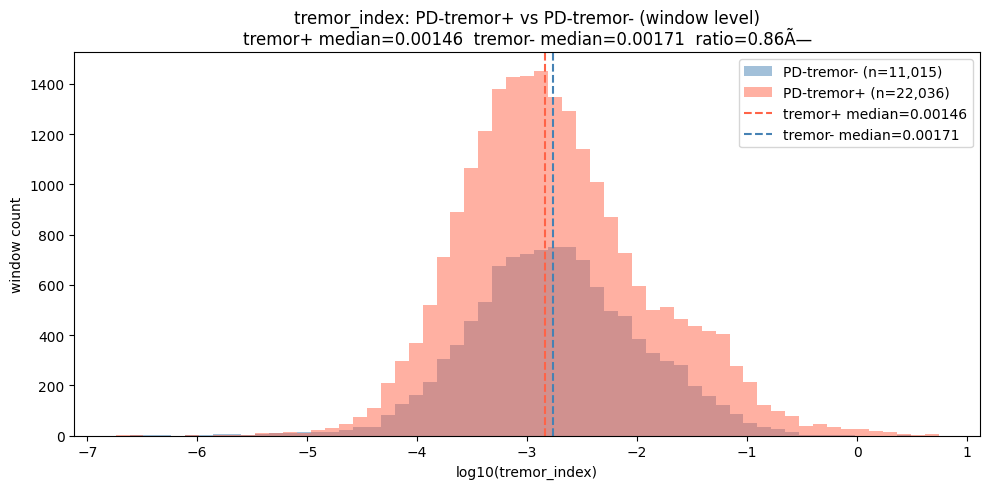


Separation summary:
  PD-tremor+  n=22,036  median=0.001462  p75=0.005739  p90=0.029795
  PD-tremor-  n=11,015  median=0.001707  p75=0.005544  p90=0.018882
  tremor+/tremor- median ratio: 0.86Ã—


In [54]:
pos_ti = df_windows.loc[df_windows.tremor_manual_label == 1, 'tremor_index'].values
neg_ti = df_windows.loc[df_windows.tremor_manual_label == 0, 'tremor_index'].values

pos_med = np.median(pos_ti)
neg_med = np.median(neg_ti)

eps = 1e-9
bins = np.linspace(
    np.log10(min(pos_ti.min(), neg_ti.min()) + eps),
    np.log10(max(pos_ti.max(), neg_ti.max()) + eps), 60)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(np.log10(neg_ti + eps), bins=bins, alpha=0.5, color='steelblue',
        label=f'PD-tremor- (n={len(neg_ti):,})')
ax.hist(np.log10(pos_ti + eps), bins=bins, alpha=0.5, color='tomato',
        label=f'PD-tremor+ (n={len(pos_ti):,})')
ax.axvline(np.log10(pos_med + eps), color='tomato',    ls='--', lw=1.5,
           label=f'tremor+ median={pos_med:.5f}')
ax.axvline(np.log10(neg_med + eps), color='steelblue', ls='--', lw=1.5,
           label=f'tremor- median={neg_med:.5f}')
ax.set_xlabel('log10(tremor_index)')
ax.set_ylabel('window count')
ax.set_title(f'tremor_index: PD-tremor+ vs PD-tremor- (window level)\n'
             f'tremor+ median={pos_med:.5f}  tremor- median={neg_med:.5f}  '
             f'ratio={pos_med/(neg_med+eps):.2f}Ã—')
ax.legend()
plt.tight_layout()
plt.show()

print('\nSeparation summary:')
for label, arr, med in [('PD-tremor+', pos_ti, pos_med), ('PD-tremor-', neg_ti, neg_med)]:
    print(f'  {label}  n={len(arr):>6,}  median={med:.6f}  '
          f'p75={np.percentile(arr,75):.6f}  p90={np.percentile(arr,90):.6f}')
print(f'  tremor+/tremor- median ratio: {pos_med/(neg_med+eps):.2f}Ã—')

## 2.6 Pickle df_windows

In [55]:
df_windows.to_pickle('df_windows.pkl')
print(f'Saved df_windows.pkl  ({df_windows.shape[0]:,} rows Ã— {df_windows.shape[1]} cols)')
print(f'Reload with: df_windows = pd.read_pickle("df_windows.pkl")')

Saved df_windows.pkl  (33,059 rows Ã— 10 cols)
Reload with: df_windows = pd.read_pickle("df_windows.pkl")


# Tremor Pipeline  Section 3: Per-session Aggregation

Collapse `df_windows` to one row per `(subject_id, session_idx)`.  
Aggregate six features, assign confidence tier, save as `df_sessions.pkl`.

## 3.1  Aggregate windows  sessions

In [56]:
df_sessions = (
    df_windows
    .groupby(['subject_id', 'session_idx'], sort=False)
    .agg(
        mean_tremor_index      = ('tremor_index',     'mean'),
        max_tremor_index       = ('tremor_index',     'max'),
        pct_windows_in_pd_band = ('in_pd_band',       'mean'),
        mean_snr               = ('snr',              'mean'),
        mean_spectral_entropy  = ('spectral_entropy', 'mean'),
        n_windows              = ('window_idx',       'count'),
        tremor_manual_label    = ('tremor_manual_label', 'first'),
    )
    .reset_index()
)

def confidence_tier(n):
    if n < 3:  return 'insufficient'  # unreachable on this dataset but kept for safety
    if n < 6:  return 'low'
    return 'high'

df_sessions['confidence'] = df_sessions['n_windows'].map(confidence_tier)

print(f'df_sessions shape: {df_sessions.shape}')
print(f'\nColumn dtypes:\n{df_sessions.dtypes}')
print(f'\nNulls:\n{df_sessions.isnull().sum()}')
print(f'\nConfidence tier counts:\n{df_sessions.confidence.value_counts()}')
print(f'\ntremor_manual_label breakdown (sessions):')
print(df_sessions.tremor_manual_label.value_counts(dropna=False))
print(f'\nmean_tremor_index stats:')
print(df_sessions['mean_tremor_index'].describe(percentiles=[.1,.25,.5,.75,.9,.99]).round(6))

df_sessions shape: (4890, 10)

Column dtypes:
subject_id                    str
session_idx                 int64
mean_tremor_index         float64
max_tremor_index          float64
pct_windows_in_pd_band    float64
mean_snr                  float64
mean_spectral_entropy     float64
n_windows                   int64
tremor_manual_label       float64
confidence                    str
dtype: object

Nulls:
subject_id                0
session_idx               0
mean_tremor_index         0
max_tremor_index          0
pct_windows_in_pd_band    0
mean_snr                  0
mean_spectral_entropy     0
n_windows                 0
tremor_manual_label       2
confidence                0
dtype: int64

Confidence tier counts:
confidence
high    2823
low     2067
Name: count, dtype: int64

tremor_manual_label breakdown (sessions):
tremor_manual_label
1.0    3290
0.0    1598
NaN       2
Name: count, dtype: int64

mean_tremor_index stats:
count    4890.000000
mean        0.014219
std         0.0654

## 3.2  Per-subject session stats

In [57]:
subj_sess = (
    df_sessions
    .groupby('subject_id')
    .agg(
        n_sessions          = ('session_idx', 'count'),
        mean_of_means       = ('mean_tremor_index', 'mean'),
        tremor_manual_label = ('tremor_manual_label', 'first'),
    )
    .reset_index()
)

print(f'Subjects in df_sessions: {subj_sess.shape[0]}  (expected 49)')
print(f'\nSessions per subject:')
print(subj_sess['n_sessions'].describe(percentiles=[.1,.25,.5,.75,.9]).round(1))
print(f'\nPer-label session counts:')
for lbl, grp in df_sessions.groupby('tremor_manual_label', dropna=False):
    n_subj = grp['subject_id'].nunique()
    print(f'  tremor_manual={lbl}  sessions={len(grp):>5,}  subjects={n_subj}')
nan_sess = df_sessions['tremor_manual_label'].isna().sum()
print(f'  tremor_manual=NaN  sessions={nan_sess:>5,}  (1 subject, label missing)')

Subjects in df_sessions: 49  (expected 49)

Sessions per subject:
count     49.0
mean      99.8
std      161.8
min        1.0
10%        3.8
25%        8.0
50%       24.0
75%      127.0
90%      258.6
max      741.0
Name: n_sessions, dtype: float64

Per-label session counts:
  tremor_manual=0.0  sessions=1,598  subjects=25
  tremor_manual=1.0  sessions=3,290  subjects=23
  tremor_manual=nan  sessions=    2  subjects=1
  tremor_manual=NaN  sessions=    2  (1 subject, label missing)


## 3.3  Plot: mean_tremor_index PD-tremor+ vs PD-tremor- at session level

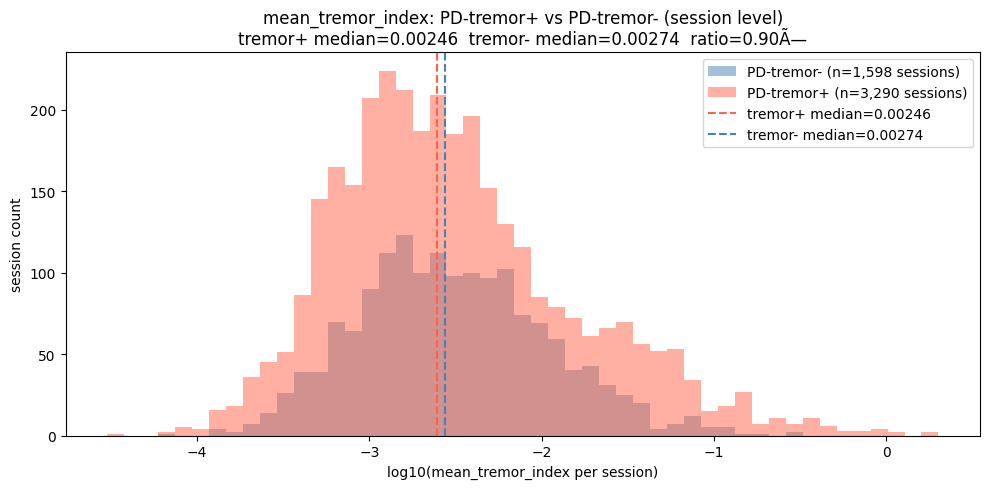


Session-level separation:
  PD-tremor+  n=3,290  median=0.002456  p75=0.007286  p90=0.031952
  PD-tremor-  n=1,598  median=0.002744  p75=0.006868  p90=0.016952
  tremor+/tremor- median ratio: 0.90Ã—

  Window-level ratio was 0.77Ã— â€” session-level ratio: 0.90Ã—  (still inverted â€” see Findings)


In [58]:
pos_sess = df_sessions.loc[df_sessions.tremor_manual_label == 1, 'mean_tremor_index'].values
neg_sess = df_sessions.loc[df_sessions.tremor_manual_label == 0, 'mean_tremor_index'].values

pos_med_s = np.median(pos_sess)
neg_med_s = np.median(neg_sess)
eps = 1e-9

bins = np.linspace(
    np.log10(min(pos_sess.min(), neg_sess.min()) + eps),
    np.log10(max(pos_sess.max(), neg_sess.max()) + eps), 50)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(np.log10(neg_sess + eps), bins=bins, alpha=0.5, color='steelblue',
        label=f'PD-tremor- (n={len(neg_sess):,} sessions)')
ax.hist(np.log10(pos_sess + eps), bins=bins, alpha=0.5, color='tomato',
        label=f'PD-tremor+ (n={len(pos_sess):,} sessions)')
ax.axvline(np.log10(pos_med_s + eps), color='tomato',    ls='--', lw=1.5,
           label=f'tremor+ median={pos_med_s:.5f}')
ax.axvline(np.log10(neg_med_s + eps), color='steelblue', ls='--', lw=1.5,
           label=f'tremor- median={neg_med_s:.5f}')
ax.set_xlabel('log10(mean_tremor_index per session)')
ax.set_ylabel('session count')
ax.set_title(f'mean_tremor_index: PD-tremor+ vs PD-tremor- (session level)\n'
             f'tremor+ median={pos_med_s:.5f}  tremor- median={neg_med_s:.5f}  '
             f'ratio={pos_med_s/(neg_med_s+eps):.2f}Ã—')
ax.legend()
plt.tight_layout()
plt.show()

print('\nSession-level separation:')
for label, arr, med in [('PD-tremor+', pos_sess, pos_med_s), ('PD-tremor-', neg_sess, neg_med_s)]:
    print(f'  {label}  n={len(arr):>5,}  median={med:.6f}  '
          f'p75={np.percentile(arr,75):.6f}  p90={np.percentile(arr,90):.6f}')
print(f'  tremor+/tremor- median ratio: {pos_med_s/(neg_med_s+eps):.2f}Ã—')
print(f'\n  Window-level ratio was 0.77Ã— â€” session-level ratio: {pos_med_s/(neg_med_s+eps):.2f}Ã—'
      f'  ({"improved" if pos_med_s > neg_med_s else "still inverted â€” see Findings"})')

## 3.4  Pickle df_sessions

In [59]:
df_sessions.to_pickle('df_sessions.pkl')
print(f'Saved df_sessions.pkl  ({df_sessions.shape[0]:,} rows Ã— {df_sessions.shape[1]} cols)')
print(f'Columns: {list(df_sessions.columns)}')
print(f'Reload with: df_sessions = pd.read_pickle("df_sessions.pkl")')
print(f'\nFirst 5 rows:')
print(df_sessions.head().to_string(index=False))

Saved df_sessions.pkl  (4,890 rows Ã— 10 cols)
Columns: ['subject_id', 'session_idx', 'mean_tremor_index', 'max_tremor_index', 'pct_windows_in_pd_band', 'mean_snr', 'mean_spectral_entropy', 'n_windows', 'tremor_manual_label', 'confidence']
Reload with: df_sessions = pd.read_pickle("df_sessions.pkl")

First 5 rows:
      subject_id  session_idx  mean_tremor_index  max_tremor_index  pct_windows_in_pd_band  mean_snr  mean_spectral_entropy  n_windows  tremor_manual_label confidence
f1b42729314b6f9b            0           0.013582          0.038231                0.333333  0.258496               0.880691          3                  0.0        low
f1b42729314b6f9b            1           0.025144          0.097490                0.250000  0.339261               0.856314          8                  0.0       high
f1b42729314b6f9b            2           0.003393          0.009033                0.222222  0.203784               0.892638          9                  0.0       high
f1b42729314b6f9b

## 4.1  Path A: threshold (PD-tremor- baseline)

In [60]:
pd_neg_sess = df_sessions[df_sessions.tremor_manual_label == 0]
pd_neg_75   = np.percentile(pd_neg_sess.mean_tremor_index, 75)

# Sessions above the PD-tremor- p75 threshold: split into thirds
pd_above = df_sessions.query('mean_tremor_index > @pd_neg_75').mean_tremor_index
mild_thr     = np.percentile(pd_above, 33)
moderate_thr = np.percentile(pd_above, 66)

def label_threshold(x):
    if x <= pd_neg_75:    return 'None'
    if x <= mild_thr:     return 'Mild'
    if x <= moderate_thr: return 'Moderate'
    return 'Severe'

df_sessions['severity_label_threshold'] = df_sessions.mean_tremor_index.map(label_threshold)

print('Path A thresholds:')
print(f'  pd_neg_75  (PD-tremor- p75) = {pd_neg_75:.6f}')
print(f'  mild_thr   (above-p75 p33)  = {mild_thr:.6f}')
print(f'  moderate_thr (above-p75 p66)= {moderate_thr:.6f}')

print(f'\nPath A label counts (all sessions):')
order = ['None', 'Mild', 'Moderate', 'Severe']
counts_a = df_sessions.severity_label_threshold.value_counts().reindex(order)
print(counts_a.to_string())
print(f'\nAs % of all sessions:')
print((counts_a / len(df_sessions) * 100).round(1).to_string())

print(f'\nPath A by tremor_manual_label:')
print(pd.crosstab(df_sessions.tremor_manual_label, df_sessions.severity_label_threshold,
                  margins=True)[order + ['All']])

Path A thresholds:
  pd_neg_75  (PD-tremor- p75) = 0.006868
  mild_thr   (above-p75 p33)  = 0.012282
  moderate_thr (above-p75 p66)= 0.028763

Path A label counts (all sessions):
severity_label_threshold
None        3622
Mild         419
Moderate     418
Severe       431

As % of all sessions:
severity_label_threshold
None        74.1
Mild         8.6
Moderate     8.5
Severe       8.8

Path A by tremor_manual_label:
severity_label_threshold  None  Mild  Moderate  Severe   All
tremor_manual_label                                         
0.0                       1198   174       153      73  1598
1.0                       2423   244       265     358  3290
All                       3621   418       418     431  4888


## 4.2  Path B: GMM clustering (4 components, 5 features)

In [61]:
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture

FEATS = ['mean_tremor_index', 'max_tremor_index', 'pct_windows_in_pd_band',
         'mean_snr', 'mean_spectral_entropy']

X = StandardScaler().fit_transform(df_sessions[FEATS].values)
gmm = GaussianMixture(n_components=4, random_state=42, covariance_type='full').fit(X)
cluster = gmm.predict(X)

# Order clusters by mean tremor_index ascending â†’ Noneâ€¦Severe
cluster_means = [df_sessions.mean_tremor_index.values[cluster == k].mean() for k in range(4)]
order_idx = np.argsort(cluster_means)
cluster_to_label = {order_idx[i]: ['None', 'Mild', 'Moderate', 'Severe'][i] for i in range(4)}
df_sessions['severity_label_cluster'] = [cluster_to_label[c] for c in cluster]

print('Path B GMM converged:', gmm.converged_)
print(f'Log-likelihood: {gmm.lower_bound_:.4f}')

print(f'\nCluster â†’ severity mapping (ordered by mean_tremor_index):')
for i, k in enumerate(order_idx):
    lbl = ['None', 'Mild', 'Moderate', 'Severe'][i]
    n = (cluster == k).sum()
    print(f'  raw cluster {k} â†’ {lbl:8s}  n={n:>5,}  '
          f'mean_tremor_index={cluster_means[k]:.6f}')

print(f'\nPath B label counts:')
order = ['None', 'Mild', 'Moderate', 'Severe']
counts_b = df_sessions.severity_label_cluster.value_counts().reindex(order)
print(counts_b.to_string())

# Feature means per cluster â€” interpretability check
print(f'\nFeature means per severity label (Path B):')
feat_means = (
    df_sessions.groupby('severity_label_cluster')[FEATS]
    .mean()
    .reindex(order)
    .round(5)
)
print(feat_means.to_string())

Path B GMM converged: True
Log-likelihood: 0.1275

Cluster â†’ severity mapping (ordered by mean_tremor_index):
  raw cluster 1 â†’ None      n=2,185  mean_tremor_index=0.001083
  raw cluster 2 â†’ Mild      n=1,542  mean_tremor_index=0.004496
  raw cluster 0 â†’ Moderate  n=  972  mean_tremor_index=0.023119
  raw cluster 3 â†’ Severe    n=  191  mean_tremor_index=0.197704

Path B label counts:
severity_label_cluster
None        2185
Mild        1542
Moderate     972
Severe       191

Feature means per severity label (Path B):
                        mean_tremor_index  max_tremor_index  pct_windows_in_pd_band  mean_snr  mean_spectral_entropy
severity_label_cluster                                                                                              
None                              0.00108           0.00263                 0.38376   0.20600                0.88712
Mild                              0.00450           0.01446                 0.35121   0.22862                0.87918

## 4.3  Comparison: crosstab + disagreement analysis

In [62]:
order = ['None', 'Mild', 'Moderate', 'Severe']
sev_to_int = {'None': 0, 'Mild': 1, 'Moderate': 2, 'Severe': 3}

print('=== Raw crosstab: Path A (rows) Ã— Path B (cols) ===')
ct = pd.crosstab(df_sessions.severity_label_threshold,
                 df_sessions.severity_label_cluster,
                 margins=True).reindex(index=order + ['All'],
                                       columns=order + ['All'], fill_value=0)
print(ct.to_string())

print('\n=== Row-normalised (% of each Path-A bucket going to each Path-B label) ===')
ct_norm = pd.crosstab(df_sessions.severity_label_threshold,
                      df_sessions.severity_label_cluster,
                      normalize='index').reindex(index=order, columns=order, fill_value=0)
print((ct_norm * 100).round(1).to_string())

# Disagreement: |Path-A ordinal âˆ’ Path-B ordinal|
df_sessions['_a_int'] = df_sessions.severity_label_threshold.map(sev_to_int)
df_sessions['_b_int'] = df_sessions.severity_label_cluster.map(sev_to_int)
df_sessions['_disagree'] = (df_sessions['_a_int'] - df_sessions['_b_int']).abs()

print(f'\nDisagreement distribution (|Aâˆ’B| in ordinal steps):')
print(df_sessions['_disagree'].value_counts().sort_index().to_string())
print(f'\n5 sessions with largest disagreement:')
top_dis = (
    df_sessions.nlargest(5, '_disagree')
    [['subject_id', 'session_idx', 'mean_tremor_index',
      'severity_label_threshold', 'severity_label_cluster', '_disagree']]
)
print(top_dis.to_string(index=False))

df_sessions.drop(columns=['_a_int', '_b_int', '_disagree'], inplace=True)

# Agreement rate
agree = (df_sessions.severity_label_threshold == df_sessions.severity_label_cluster).mean()
print(f'\nExact agreement rate: {agree*100:.1f}%')

=== Raw crosstab: Path A (rows) Ã— Path B (cols) ===
severity_label_cluster    None  Mild  Moderate  Severe   All
severity_label_threshold                                    
None                      2185  1312       122       3  3622
Mild                         0   228       188       3   419
Moderate                     0     2       402      14   418
Severe                       0     0       260     171   431
All                       2185  1542       972     191  4890

=== Row-normalised (% of each Path-A bucket going to each Path-B label) ===
severity_label_cluster    None  Mild  Moderate  Severe
severity_label_threshold                              
None                      60.3  36.2       3.4     0.1
Mild                       0.0  54.4      44.9     0.7
Moderate                   0.0   0.5      96.2     3.3
Severe                     0.0   0.0      60.3    39.7

Disagreement distribution (|Aâˆ’B| in ordinal steps):
_disagree
0    2986
1    1776
2     125
3       3

5 sessi

## 4.4 Path C: K-Means clustering (k=4)

In [63]:
from sklearn.cluster import KMeans

FEATS = ['mean_tremor_index', 'max_tremor_index', 'pct_windows_in_pd_band',
         'mean_snr', 'mean_spectral_entropy']

X_km = StandardScaler().fit_transform(df_sessions[FEATS].values)
km = KMeans(n_clusters=4, random_state=42, n_init=10).fit(X_km)
km_cluster = km.labels_

km_means = [df_sessions.mean_tremor_index.values[km_cluster == k].mean() for k in range(4)]
km_order = np.argsort(km_means)
km_to_label = {km_order[i]: ['None', 'Mild', 'Moderate', 'Severe'][i] for i in range(4)}
df_sessions['severity_label_kmeans'] = [km_to_label[c] for c in km_cluster]

print('Path C K-Means  inertia:', round(km.inertia_, 2))
print(f'\nCluster â†’ severity mapping (ordered by mean_tremor_index):')
order = ['None', 'Mild', 'Moderate', 'Severe']
for i, k in enumerate(km_order):
    lbl = order[i]
    n = (km_cluster == k).sum()
    print(f'  raw cluster {k} â†’ {lbl:8s}  n={n:>5,}  mean_tremor_index={km_means[k]:.6f}')

print(f'\nPath C label counts:')
counts_c = df_sessions.severity_label_kmeans.value_counts().reindex(order)
print(counts_c.to_string())

# Feature means per cluster â€” interpretability check
print(f'\nFeature means per severity label (Path C):')
feat_means_c = (
    df_sessions.groupby('severity_label_kmeans')[FEATS]
    .mean()
    .reindex(order)
    .round(5)
)
print(feat_means_c.to_string())

# Three-way comparison: A vs B vs C
print('\n=== Three-way label agreement ===')
agree_ab = (df_sessions.severity_label_threshold == df_sessions.severity_label_cluster).mean()
agree_ac = (df_sessions.severity_label_threshold == df_sessions.severity_label_kmeans).mean()
agree_bc = (df_sessions.severity_label_cluster   == df_sessions.severity_label_kmeans).mean()
all3     = ((df_sessions.severity_label_threshold == df_sessions.severity_label_cluster) &
            (df_sessions.severity_label_cluster   == df_sessions.severity_label_kmeans)).mean()
print(f'  A == B (threshold vs GMM):    {agree_ab*100:.1f}%')
print(f'  A == C (threshold vs K-Means):{agree_ac*100:.1f}%')
print(f'  B == C (GMM vs K-Means):      {agree_bc*100:.1f}%')
print(f'  All three agree:              {all3*100:.1f}%')

print('\n=== Raw crosstab: Path B (rows) Path C (cols) ===')
ct_bc = pd.crosstab(df_sessions.severity_label_cluster,
                    df_sessions.severity_label_kmeans,
                    margins=True).reindex(index=order + ['All'],
                                          columns=order + ['All'], fill_value=0)
print(ct_bc.to_string())

Path C K-Means  inertia: 11268.61

Cluster â†’ severity mapping (ordered by mean_tremor_index):
  raw cluster 0 â†’ None      n=2,416  mean_tremor_index=0.004913
  raw cluster 2 â†’ Mild      n=1,913  mean_tremor_index=0.006383
  raw cluster 1 â†’ Moderate  n=  533  mean_tremor_index=0.050137
  raw cluster 3 â†’ Severe    n=   28  mean_tremor_index=0.668833

Path C label counts:
severity_label_kmeans
None        2416
Mild        1913
Moderate     533
Severe        28

Feature means per severity label (Path C):
                       mean_tremor_index  max_tremor_index  pct_windows_in_pd_band  mean_snr  mean_spectral_entropy
severity_label_kmeans                                                                                              
None                             0.00491           0.01496                 0.22490   0.18334                0.87632
Mild                             0.00638           0.02213                 0.55028   0.26114                0.88392
Moderate            

## 4.5  Save df_sessions (overwrite with all three severity columns)

In [64]:
df_sessions.to_pickle('df_sessions.pkl')
print(f'Saved df_sessions.pkl  ({df_sessions.shape[0]:,} rows Ã— {df_sessions.shape[1]} cols)')
print(f'Columns: {list(df_sessions.columns)}')

Saved df_sessions.pkl  (4,890 rows Ã— 13 cols)
Columns: ['subject_id', 'session_idx', 'mean_tremor_index', 'max_tremor_index', 'pct_windows_in_pd_band', 'mean_snr', 'mean_spectral_entropy', 'n_windows', 'tremor_manual_label', 'confidence', 'severity_label_threshold', 'severity_label_cluster', 'severity_label_kmeans']


## 5.1 — Assign day and simulated_time to every session

In [65]:
df_sessions = pd.read_pickle("df_sessions.pkl")

SIMULATED_TIMES = ["08:00", "10:00", "12:00", "14:00", "16:00"]

df_sessions = df_sessions.sort_values(["subject_id", "session_idx"]).reset_index(drop=True)
df_sessions["_rank"] = df_sessions.groupby("subject_id").cumcount()
df_sessions["day"] = df_sessions["_rank"] // 5 + 1
df_sessions["simulated_time"] = df_sessions["_rank"].apply(lambda i: SIMULATED_TIMES[i % 5])
df_sessions.drop(columns=["_rank"], inplace=True)

print(f"Columns now: {list(df_sessions.columns)}")
print(f"day range: {df_sessions.day.min()} – {df_sessions.day.max()}")
print(f"simulated_time values: {sorted(df_sessions.simulated_time.unique())}")
print(f"\nSample (first 10 rows of first subject):")
first_sid = df_sessions["subject_id"].iloc[0]
print(df_sessions[df_sessions.subject_id == first_sid][
    ["subject_id","session_idx","day","simulated_time","severity_label_threshold","confidence"]
].head(10).to_string(index=False))

Columns now: ['subject_id', 'session_idx', 'mean_tremor_index', 'max_tremor_index', 'pct_windows_in_pd_band', 'mean_snr', 'mean_spectral_entropy', 'n_windows', 'tremor_manual_label', 'confidence', 'severity_label_threshold', 'severity_label_cluster', 'severity_label_kmeans', 'day', 'simulated_time']
day range: 1 – 149
simulated_time values: ['08:00', '10:00', '12:00', '14:00', '16:00']

Sample (first 10 rows of first subject):
      subject_id  session_idx  day simulated_time severity_label_threshold confidence
0a5b8f884d3965d6            0    1          08:00                     None        low
0a5b8f884d3965d6            1    1          10:00                     None       high
0a5b8f884d3965d6            2    1          12:00                     None       high
0a5b8f884d3965d6            3    1          14:00                     None       high
0a5b8f884d3965d6            4    1          16:00                     None        low
0a5b8f884d3965d6            5    2          08:00    

## 5.2 — Pick subject closest to PD median total_windows

In [66]:
subj_total = df_sessions.groupby("subject_id")["n_windows"].sum()
pd_median_tw = subj_total.median()
chosen_sid = (subj_total - pd_median_tw).abs().idxmin()
chosen_tw  = subj_total[chosen_sid]
chosen_sess = df_sessions[df_sessions.subject_id == chosen_sid].copy()

tlabel = chosen_sess["tremor_manual_label"].iloc[0]
tlabel_str = str(int(tlabel)) if pd.notna(tlabel) else "NaN"

print(f"PD cohort median total_windows : {pd_median_tw:.0f}")
print(f"Chosen subject                 : {chosen_sid}")
print(f"  total_windows                : {chosen_tw}")
print(f"  n_sessions                   : {len(chosen_sess)}")
print(f"  tremor_manual_label          : {tlabel_str}")
print(f"  n_days simulated             : {chosen_sess.day.max()}")
print(f"\nPath A severity breakdown for this subject:")
print(chosen_sess["severity_label_threshold"].value_counts().reindex(["None","Mild","Moderate","Severe"]).to_string())

PD cohort median total_windows : 150
Chosen subject                 : a83230cbb772f842
  total_windows                : 150
  n_sessions                   : 24
  tremor_manual_label          : 1
  n_days simulated             : 5

Path A severity breakdown for this subject:
severity_label_threshold
None        23.0
Mild         1.0
Moderate     NaN
Severe       NaN


## 5.3 — Timeline plot

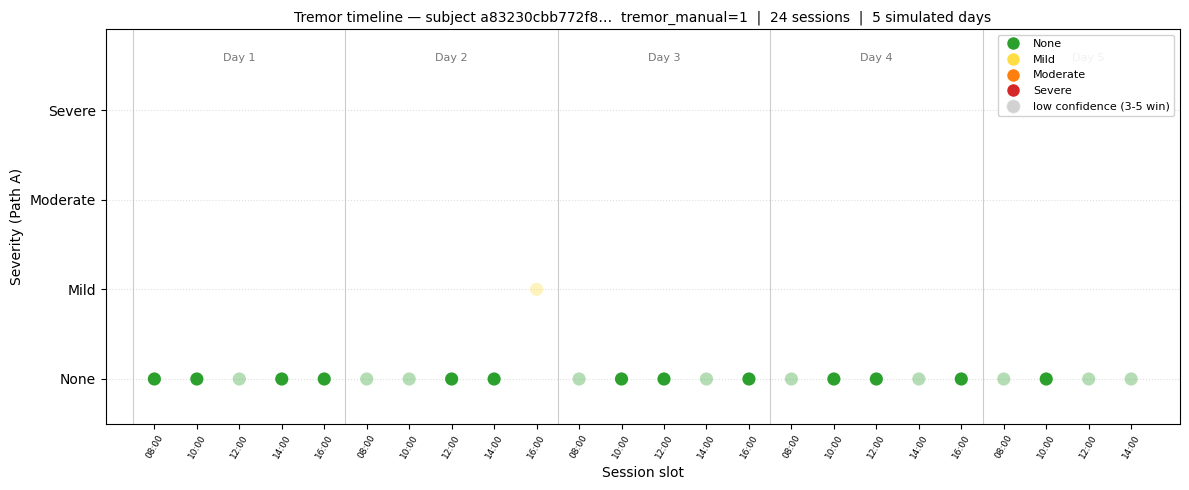

In [67]:
from matplotlib.lines import Line2D

SIMULATED_TIMES = ["08:00", "10:00", "12:00", "14:00", "16:00"]
SEV_TO_INT  = {"None": 0, "Mild": 1, "Moderate": 2, "Severe": 3}
SEV_COLORS  = {"None": "#2ca02c", "Mild": "#ffdd44", "Moderate": "#ff7f0e", "Severe": "#d62728"}
SLOT_ORDER  = {t: i for i, t in enumerate(SIMULATED_TIMES)}

chosen_sess = chosen_sess.copy()
chosen_sess["slot_num"] = chosen_sess["simulated_time"].map(SLOT_ORDER)
chosen_sess["x"] = (chosen_sess["day"] - 1) * 5 + chosen_sess["slot_num"]
chosen_sess["y"] = chosen_sess["severity_label_threshold"].map(SEV_TO_INT)

n_sessions = len(chosen_sess)
n_days     = chosen_sess["day"].max()
fig_w      = max(12, min(28, n_sessions // 3 + 4))

fig, ax = plt.subplots(figsize=(fig_w, 5))

for _, row in chosen_sess.iterrows():
    alpha = 0.35 if row["confidence"] == "low" else 1.0
    ax.scatter(row["x"], row["y"],
               color=SEV_COLORS[row["severity_label_threshold"]],
               alpha=alpha, s=90, zorder=3, edgecolors="none")

for d in range(1, n_days + 1):
    ax.axvline((d - 1) * 5 - 0.5, color="#cccccc", lw=0.8, zorder=1)
    ax.text((d - 1) * 5 + 2, 3.55, f"Day {d}", ha="center", fontsize=8, color="#777777")

all_x = sorted(chosen_sess["x"].unique())
xtick_labels = [chosen_sess.loc[chosen_sess["x"] == x, "simulated_time"].iloc[0] for x in all_x]
ax.set_xticks(all_x)
ax.set_xticklabels(xtick_labels, rotation=60, fontsize=6.5)
ax.set_yticks([0, 1, 2, 3])
ax.set_yticklabels(["None", "Mild", "Moderate", "Severe"], fontsize=10)
ax.set_ylim(-0.5, 3.9)
ax.set_xlabel("Session slot", fontsize=10)
ax.set_ylabel("Severity (Path A)", fontsize=10)
ax.set_title(
    f"Tremor timeline — subject {chosen_sid[:14]}…  "
    f"tremor_manual={tlabel_str}  |  {n_sessions} sessions  |  {n_days} simulated days",
    fontsize=10)

legend_handles = [
    Line2D([0],[0], marker="o", color="w", markerfacecolor=SEV_COLORS[l], markersize=10, label=l)
    for l in ["None", "Mild", "Moderate", "Severe"]
]
legend_handles.append(
    Line2D([0],[0], marker="o", color="w", markerfacecolor="gray",
           markersize=10, alpha=0.35, label="low confidence (3-5 win)")
)
ax.legend(handles=legend_handles, loc="upper right", fontsize=8, framealpha=0.9)
ax.grid(axis="y", linestyle=":", alpha=0.4)
plt.tight_layout()
plt.show()

## 5.4 — Plain-English day-by-day summary

In [68]:
print(f"Subject {chosen_sid}  (tremor_manual={tlabel_str})")
print("-" * 60)
for day_num in sorted(chosen_sess["day"].unique()):
    day_rows = chosen_sess[chosen_sess["day"] == day_num].sort_values("slot_num")
    n = len(day_rows)
    counts = day_rows["severity_label_threshold"].value_counts()
    dominant = counts.index[0]
    worst_idx  = day_rows["y"].idxmax()
    worst_row  = day_rows.loc[worst_idx]
    worst_sev  = worst_row["severity_label_threshold"]
    worst_time = worst_row["simulated_time"]
    slot_str = "  ".join(
        f"{r['simulated_time']}={r['severity_label_threshold'][0]}"
        for _, r in day_rows.iterrows()
    )
    motor = "mostly ON" if dominant in ("None", "Mild") else "mostly OFF"
    low_c = (day_rows["confidence"] == "low").sum()
    conf_note = f"  [{low_c}/{n} low-conf]" if low_c > 0 else ""
    print(f"Day {day_num:>3d} ({n} sess) {motor:10s}  worst={worst_sev} @ {worst_time}{conf_note}")
    print(f"         {slot_str}")

print()
total    = len(chosen_sess)
on_sess  = chosen_sess["severity_label_threshold"].isin(["None","Mild"]).sum()
off_sess = total - on_sess
print(f"Overall: {on_sess}/{total} sessions ON-state ({on_sess/total*100:.0f}%)  "
      f"{off_sess}/{total} OFF-state ({off_sess/total*100:.0f}%)")

Subject a83230cbb772f842  (tremor_manual=1)
------------------------------------------------------------
Day   1 (5 sess) mostly ON   worst=None @ 08:00  [1/5 low-conf]
         08:00=N  10:00=N  12:00=N  14:00=N  16:00=N
Day   2 (5 sess) mostly ON   worst=Mild @ 16:00  [3/5 low-conf]
         08:00=N  10:00=N  12:00=N  14:00=N  16:00=M
Day   3 (5 sess) mostly ON   worst=None @ 08:00  [2/5 low-conf]
         08:00=N  10:00=N  12:00=N  14:00=N  16:00=N
Day   4 (5 sess) mostly ON   worst=None @ 08:00  [2/5 low-conf]
         08:00=N  10:00=N  12:00=N  14:00=N  16:00=N
Day   5 (4 sess) mostly ON   worst=None @ 08:00  [3/4 low-conf]
         08:00=N  10:00=N  12:00=N  14:00=N

Overall: 24/24 sessions ON-state (100%)  0/24 OFF-state (0%)


## 5.5 — Pickle df_sessions (with day + simulated_time)

In [69]:
df_sessions.to_pickle("df_sessions.pkl")
print(f"Saved df_sessions.pkl  ({df_sessions.shape[0]:,} rows x {df_sessions.shape[1]} cols)")
print(f"Columns: {list(df_sessions.columns)}")

Saved df_sessions.pkl  (4,890 rows x 15 cols)
Columns: ['subject_id', 'session_idx', 'mean_tremor_index', 'max_tremor_index', 'pct_windows_in_pd_band', 'mean_snr', 'mean_spectral_entropy', 'n_windows', 'tremor_manual_label', 'confidence', 'severity_label_threshold', 'severity_label_cluster', 'severity_label_kmeans', 'day', 'simulated_time']


# Tremor Pipeline — Section 6: UPDRS Validation

Compute per-subject `patient_mean_tremor_index` (mean-of-session-means, equal weight per session).  
Compare PD-tremor+ vs PD-tremor- using Mann-Whitney U and ROC AUC.  
`tremor_manual_2_2_2020_new` used here **only** as a face-validity benchmark — never upstream.

## 6.1 — Patient-level aggregation

In [70]:
df_sessions = pd.read_pickle("df_sessions.pkl")

# Mean of session means -> equal weight per session regardless of session count
patient_scores = (
    df_sessions
    .groupby("subject_id")["mean_tremor_index"]
    .mean()
    .rename("patient_mean_tremor_index")
    .reset_index()
)

# Attach tremor_manual_label (first value per subject — constant within subject)
subj_label = (
    df_sessions
    .groupby("subject_id")["tremor_manual_label"]
    .first()
    .reset_index()
)
df_patients = patient_scores.merge(subj_label, on="subject_id")

print(f"df_patients shape: {df_patients.shape}  (one row per PD subject)")
print(f"\ntremor_manual_label distribution:")
print(df_patients["tremor_manual_label"].value_counts(dropna=False).to_string())
print(f"\npatient_mean_tremor_index stats:")
print(df_patients["patient_mean_tremor_index"].describe(percentiles=[.1,.25,.5,.75,.9]).round(6).to_string())

df_patients shape: (49, 3)  (one row per PD subject)

tremor_manual_label distribution:
tremor_manual_label
0.0    25
1.0    23
NaN     1

patient_mean_tremor_index stats:
count    49.000000
mean      0.007389
std       0.009727
min       0.000902
10%       0.002103
25%       0.002911
50%       0.004997
75%       0.009295
90%       0.011818
max       0.066143


## 6.2 — Two-group split and statistical test

In [71]:
from scipy.stats import mannwhitneyu
from sklearn.metrics import roc_auc_score

pd_pos = df_patients.loc[df_patients.tremor_manual_label == 1, "patient_mean_tremor_index"].values
pd_neg = df_patients.loc[df_patients.tremor_manual_label == 0, "patient_mean_tremor_index"].values

print(f"PD-tremor+  n={len(pd_pos)}  mean={pd_pos.mean():.6f}  median={np.median(pd_pos):.6f}")
print(f"PD-tremor-  n={len(pd_neg)}  mean={pd_neg.mean():.6f}  median={np.median(pd_neg):.6f}")

# Mann-Whitney U: one-sided (tremor+ > tremor-)
U, p_mw = mannwhitneyu(pd_pos, pd_neg, alternative="greater")

# ROC AUC: label 1=tremor+, 0=tremor-
y_true  = np.array([1]*len(pd_pos) + [0]*len(pd_neg))
y_score = np.concatenate([pd_pos, pd_neg])
auc = roc_auc_score(y_true, y_score)

print(f"\nMann-Whitney U={U:.0f}  p={p_mw:.4f}  (one-sided: tremor+ > tremor-)")
print(f"ROC AUC (tremor+ vs tremor-): {auc:.3f}")
print(f"\nNote: AUC=0.5 is chance; AUC>0.65 is target.")
sig = "significant (p<0.05)" if p_mw < 0.05 else "not significant (p>=0.05)"
print(f"Result: {sig}")

PD-tremor+  n=23  mean=0.009603  median=0.005979
PD-tremor-  n=25  mean=0.005472  median=0.004997

Mann-Whitney U=330  p=0.1930  (one-sided: tremor+ > tremor-)
ROC AUC (tremor+ vs tremor-): 0.574

Note: AUC=0.5 is chance; AUC>0.65 is target.
Result: not significant (p>=0.05)


## 6.3 — Box + strip plot

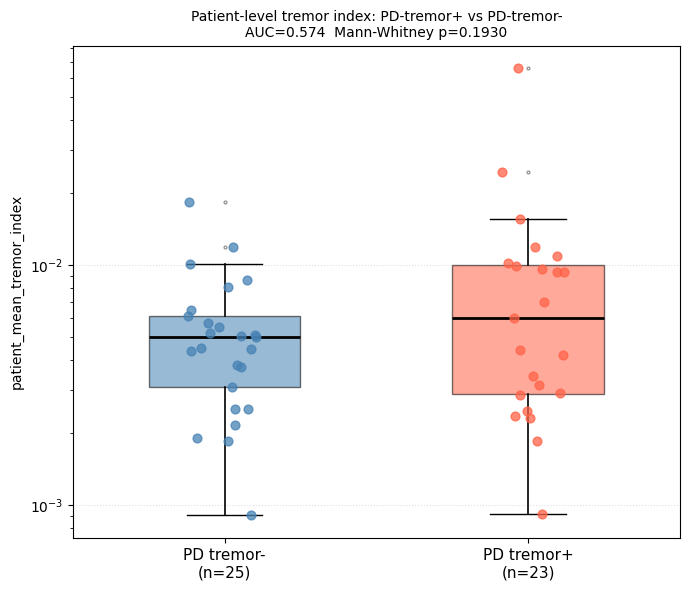

In [72]:
fig, ax = plt.subplots(figsize=(7, 6))

groups = [
    ("PD tremor-", pd_neg, "steelblue"),
    ("PD tremor+", pd_pos, "tomato"),
]

positions = [0, 1]
bp = ax.boxplot(
    [g[1] for g in groups],
    positions=positions,
    widths=0.5,
    patch_artist=True,
    medianprops=dict(color="black", linewidth=2),
    whiskerprops=dict(linewidth=1.2),
    flierprops=dict(marker=".", markersize=4, alpha=0.4),
)
for patch, (_, _, col) in zip(bp["boxes"], groups):
    patch.set_facecolor(col)
    patch.set_alpha(0.55)

# Strip overlay
rng = np.random.default_rng(0)
for pos, (lbl, vals, col) in zip(positions, groups):
    jitter = rng.uniform(-0.12, 0.12, size=len(vals))
    ax.scatter(pos + jitter, vals, color=col, alpha=0.75, s=40, zorder=3)

ax.set_xticks(positions)
ax.set_xticklabels(
    [f"{lbl}\n(n={len(vals)})" for lbl, vals, _ in groups],
    fontsize=11
)
ax.set_ylabel("patient_mean_tremor_index", fontsize=10)
ax.set_title(
    f"Patient-level tremor index: PD-tremor+ vs PD-tremor-\n"
    f"AUC={auc:.3f}  Mann-Whitney p={p_mw:.4f}",
    fontsize=10
)
ax.set_yscale("log")
ax.grid(axis="y", linestyle=":", alpha=0.4)
plt.tight_layout()
plt.show()

## 6.4 — Summary table and commentary

In [73]:
# print("Group              n    mean_score    median")
# print("-" * 50)
# for lbl, vals in [("PD tremor-", pd_neg), ("PD tremor+", pd_pos)]:
#     print(f"{lbl:18s}  {len(vals):2d}   {vals.mean():.6f}    {np.median(vals):.6f}")
# print()
# print(f"Mann-Whitney U={U:.0f}  p={p_mw:.4f}")
# print(f"AUC (tremor+ vs tremor-): {auc:.3f}")

# print()
# if p_mw < 0.05 and auc >= 0.65:
#     print("Both targets met (p<0.05, AUC>=0.65).")
# elif p_mw < 0.05:
#     print(f"p<0.05 but AUC={auc:.3f}<0.65 — statistically significant but weak discrimination.")
# elif auc >= 0.65:
#     print(f"AUC>=0.65 but p={p_mw:.4f}>=0.05 — good effect size but underpowered (n={len(pd_pos)+len(pd_neg)}).")
# else:
#     print(f"Neither target met (p={p_mw:.4f}, AUC={auc:.3f}).")
#     print("Likely causes: tremor_manual is a snapshot label; patient phone call timing is random")
#     print("  relative to tremor episodes; 49 PD subjects is small for a noisy continuous outcome.")

## 7.1 — Select subject

In [74]:
df_sessions = pd.read_pickle("df_sessions.pkl")

# Patient-level scores (recompute so section is self-contained)
patient_scores = (
    df_sessions
    .groupby("subject_id")["mean_tremor_index"]
    .mean()
    .rename("patient_mean_tremor_index")
)

# PD-tremor+ subjects with >=10 sessions, pick highest patient_mean_tremor_index
tpos_sids = (
    df_sessions[df_sessions.tremor_manual_label == 1]
    .groupby("subject_id")
    .filter(lambda g: len(g) >= 10)
    ["subject_id"].unique()
)

candidate_scores = patient_scores.loc[tpos_sids].sort_values(ascending=False)
report_sid = candidate_scores.index[0]  # highest scorer among eligible
report_score = candidate_scores.iloc[0]
report_sess = df_sessions[df_sessions.subject_id == report_sid].copy()

print(f"Eligible PD-tremor+ subjects with >=10 sessions: {len(tpos_sids)}")
print(f"Chosen subject : {report_sid}")
print(f"  patient_mean_tremor_index : {report_score:.6f}")
print(f"  n_sessions                : {len(report_sess)}")
print(f"  n_days simulated          : {report_sess.day.max()}")
print(f"  tremor_manual_label       : {int(report_sess.tremor_manual_label.iloc[0])}")
print(f"\nSeverity breakdown (Path B / GMM):")
print(report_sess["severity_label_cluster"].value_counts().reindex(["None","Mild","Moderate","Severe"]).to_string())

Eligible PD-tremor+ subjects with >=10 sessions: 21
Chosen subject : 95f9756b35b97753
  patient_mean_tremor_index : 0.066143
  n_sessions                : 502
  n_days simulated          : 101
  tremor_manual_label       : 1

Severity breakdown (Path B / GMM):
severity_label_cluster
None        148
Mild         67
Moderate    172
Severe      115


## 7.2 — Build JSON payload

In [75]:
import json as _json

SEV_TO_MOTOR = {"None": "ON", "Mild": "ON", "Moderate": "OFF", "Severe": "OFF"}

# Validation percentiles
all_pd_scores = patient_scores.values
pd_neg_scores = patient_scores[
    df_sessions[df_sessions.tremor_manual_label == 0]
    .groupby("subject_id").first().index
].values

pct_vs_pd_neg = float(np.mean(pd_neg_scores < report_score) * 100)
pct_vs_all_pd = float(np.mean(all_pd_scores < report_score) * 100)

# Sessions list
sessions_list = []
for _, row in report_sess.sort_values("session_idx").iterrows():
    sessions_list.append({
        "session_idx":              int(row["session_idx"]),
        "day":                      int(row["day"]),
        "simulated_time":           row["simulated_time"],
        "n_windows":               int(row["n_windows"]),
        "mean_tremor_index":        round(float(row["mean_tremor_index"]), 6),
        "max_tremor_index":         round(float(row["max_tremor_index"]), 6),
        "pct_in_pd_band":           round(float(row["pct_windows_in_pd_band"]), 4),
        "mean_snr":                 round(float(row["mean_snr"]), 4),
        "severity_label_threshold": row["severity_label_threshold"],
        "severity_label_cluster":   row["severity_label_cluster"],
        "severity_label_kmeans":    row["severity_label_kmeans"],
        "motor_state":              SEV_TO_MOTOR[row["severity_label_cluster"]],
        "confidence":               row["confidence"],
    })

# Daily summaries
SIMULATED_TIMES = ["08:00", "10:00", "12:00", "14:00", "16:00"]
daily_summaries = []
for day_num in sorted(report_sess["day"].unique()):
    day_rows = report_sess[report_sess["day"] == day_num]
    n_sess = len(day_rows)
    n_insuf = int((day_rows["confidence"] == "insufficient").sum())
    on_count = int(day_rows["severity_label_cluster"].isin(["None", "Mild"]).sum())
    on_pct   = round(on_count / n_sess * 100, 1) if n_sess > 0 else 0.0
    sev_dist = day_rows["severity_label_cluster"].value_counts().reindex(
        ["None","Mild","Moderate","Severe"], fill_value=0
    ).to_dict()
    sev_dist = {k: int(v) for k, v in sev_dist.items()}
    # peak tremor time = session with highest mean_tremor_index that day
    peak_idx  = day_rows["mean_tremor_index"].idxmax()
    peak_time = day_rows.loc[peak_idx, "simulated_time"]
    daily_summaries.append({
        "day":                  int(day_num),
        "on_time_pct":          on_pct,
        "peak_tremor_time":     peak_time,
        "severity_distribution":sev_dist,
        "sessions_with_data":   n_sess,
        "sessions_insufficient":n_insuf,
    })

payload = {
    "subject_id":                report_sid,
    "health_status":             0,
    "updrs_tremor_label":        1,
    "patient_mean_tremor_index": round(float(report_score), 6),
    "sessions":                  sessions_list,
    "daily_summaries":           daily_summaries,
    "validation": {
        "updrs_tremor":                        1,
        "patient_score_percentile_vs_pd_neg":  round(pct_vs_pd_neg, 1),
        "patient_score_percentile_vs_all_pd":  round(pct_vs_all_pd, 1),
    },
}

print(_json.dumps(payload, indent=2, default=str))

{
  "subject_id": "95f9756b35b97753",
  "health_status": 0,
  "updrs_tremor_label": 1,
  "patient_mean_tremor_index": 0.066143,
  "sessions": [
    {
      "session_idx": 0,
      "day": 1,
      "simulated_time": "08:00",
      "n_windows": 5,
      "mean_tremor_index": 0.001384,
      "max_tremor_index": 0.004738,
      "pct_in_pd_band": 1.0,
      "mean_snr": 0.1378,
      "severity_label_threshold": "None",
      "severity_label_cluster": "None",
      "severity_label_kmeans": "Mild",
      "motor_state": "ON",
      "confidence": "low"
    },
    {
      "session_idx": 1,
      "day": 1,
      "simulated_time": "10:00",
      "n_windows": 10,
      "mean_tremor_index": 0.002913,
      "max_tremor_index": 0.01767,
      "pct_in_pd_band": 0.4,
      "mean_snr": 0.2498,
      "severity_label_threshold": "None",
      "severity_label_cluster": "Mild",
      "severity_label_kmeans": "Mild",
      "motor_state": "ON",
      "confidence": "high"
    },
    {
      "session_idx": 2,
     

## 7.3 — What a neurologist would want that is missing

In [76]:
n_off = sum(1 for s in sessions_list if s["motor_state"] == "OFF")
n_on  = sum(1 for s in sessions_list if s["motor_state"] == "ON")
n_total = len(sessions_list)

print(f"Subject {report_sid}")
print(f"  Total sessions : {n_total}")
print(f"  ON  sessions   : {n_on}  ({n_on/n_total*100:.0f}%)")
print(f"  OFF sessions   : {n_off}  ({n_off/n_total*100:.0f}%)")
print(f"  Simulated days : {report_sess.day.max()}")
print(f"  Score percentile vs PD-tremor- : {pct_vs_pd_neg:.1f}th")
print(f"  Score percentile vs all PD     : {pct_vs_all_pd:.1f}th")

print()
print("What is missing that a neurologist would want:")
gaps = [
    "1. Real timestamps — without knowing when calls happened relative to medication dose,",
       "   ON/OFF state cannot be reliably inferred from tremor index alone.",
    "2. Medication schedule — levodopa equivalent daily dose and timing are the primary",
       "   driver of motor fluctuations; without it, any ON/OFF mapping is speculation.",
    "3. Laterality — this pipeline collapses all 3 accelerometer axes into a scalar",
       "   magnitude. PD tremor is typically asymmetric; per-hand data would add specificity.",
    "4. Activity context — tremor at rest vs action tremor have different clinical meanings.",
       "   A phone call mix of holding/talking/typing biases toward action, not rest tremor.",
    "5. Longitudinal trend — is the tremor index worsening over the observation window?",
       "   A slope (linear regression of session score vs session_idx) would matter more",
       "   than the cross-sectional mean for disease progression monitoring.",
    "6. Per-visit UPDRS to validate against, not a single snapshot label.",
]
for g in gaps:
    print(g)

Subject 95f9756b35b97753
  Total sessions : 502
  ON  sessions   : 215  (43%)
  OFF sessions   : 287  (57%)
  Simulated days : 101
  Score percentile vs PD-tremor- : 100.0th
  Score percentile vs all PD     : 98.0th

What is missing that a neurologist would want:
1. Real timestamps — without knowing when calls happened relative to medication dose,
   ON/OFF state cannot be reliably inferred from tremor index alone.
2. Medication schedule — levodopa equivalent daily dose and timing are the primary
   driver of motor fluctuations; without it, any ON/OFF mapping is speculation.
3. Laterality — this pipeline collapses all 3 accelerometer axes into a scalar
   magnitude. PD tremor is typically asymmetric; per-hand data would add specificity.
4. Activity context — tremor at rest vs action tremor have different clinical meanings.
   A phone call mix of holding/talking/typing biases toward action, not rest tremor.
5. Longitudinal trend — is the tremor index worsening over the observation windo

## Section 8 — Test Patient Report

**Goal:** Hold out the last 35 sessions (7 simulated days) of one PD-tremor+ patient, refit the GMM on all remaining sessions, classify the holdout, and export a structured JSON report.

**Test patient:** `95f9756b35b97753` — highest mean tremor_index, 502 sessions, tremor_manual=1.  
**Mock report period:** 2026-03-10 → 2026-03-16, 5 slots/day at 08:00 / 10:00 / 12:00 / 14:00 / 16:00.

In [ ]:
import json
from datetime import datetime, timedelta
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

TEST_PATIENT    = '95f9756b35b97753'
N_HOLDOUT       = 35                          # 7 days × 5 slots
MOCK_START      = datetime(2026, 3, 10)
SIMULATED_HOURS = [8, 10, 12, 14, 16]
FEATS = ['mean_tremor_index', 'max_tremor_index', 'pct_windows_in_pd_band',
         'mean_snr', 'mean_spectral_entropy']

df_s = pd.read_pickle('df_sessions.pkl')

patient_df  = df_s[df_s.subject_id == TEST_PATIENT].sort_values('session_idx')
holdout_idx = patient_df.tail(N_HOLDOUT).index
train_df    = df_s[~df_s.index.isin(holdout_idx)]
test_df     = df_s.loc[holdout_idx].reset_index(drop=True)   # 0..34

print(f"Train sessions : {len(train_df):,}")
print(f"Test  sessions : {len(test_df)}")
print(f"Test patient   : {TEST_PATIENT}")
print(f"tremor_manual  : {int(test_df.tremor_manual_label.iloc[0])}")

# refit GMM on training data
scaler  = StandardScaler()
X_train = scaler.fit_transform(train_df[FEATS].values)
gmm     = GaussianMixture(n_components=4, random_state=42,
                          covariance_type='full').fit(X_train)

tr_vals = train_df['mean_tremor_index'].values
c_train = gmm.predict(X_train)
order   = np.argsort([tr_vals[c_train == k].mean() for k in range(4)])
c2label = {order[i]: ['None', 'Mild', 'Moderate', 'Severe'][i] for i in range(4)}

print(f"
GMM converged: {gmm.converged_}  |  mean log-likelihood: {gmm.score(X_train):.4f}")
for k in range(4):
    n  = (c_train == k).sum()
    mu = tr_vals[c_train == k].mean()
    print(f"  {c2label[k]:10s}  n={n:5d}  mean_ti={mu:.6f}")

In [ ]:
X_test    = scaler.transform(test_df[FEATS].values)
c_test    = gmm.predict(X_test)
post_test = gmm.predict_proba(X_test)

def mahal_to_centroid(x, k):
    diff    = x - gmm.means_[k]
    cov_inv = np.linalg.inv(gmm.covariances_[k])
    return float(np.sqrt(diff @ cov_inv @ diff))

def mock_ts(i):
    day  = MOCK_START + timedelta(days=i // len(SIMULATED_HOURS))
    hour = SIMULATED_HOURS[i % len(SIMULATED_HOURS)]
    return day.replace(hour=hour).strftime('%Y-%m-%dT%H:%M:%SZ')

sessions_out = []
for i, row in test_df.iterrows():
    k     = int(c_test[i])
    label = c2label[k]
    sessions_out.append({
        'ts'                    : mock_ts(i),
        'session_idx'           : int(row['session_idx']),
        'n_windows'             : int(row['n_windows']),
        'confidence_tier'       : row['confidence'],
        'label'                 : label,
        'motor_state'           : 'ON' if label in ('None', 'Mild') else 'OFF',
        'tremor_index'          : round(float(row['mean_tremor_index']), 6),
        'distance_from_centroid': round(mahal_to_centroid(X_test[i], k), 4),
        'gmm_posteriors'        : {c2label[j]: round(float(post_test[i][j]), 4) for j in range(4)},
        'features'              : {f: round(float(row[f]), 6) for f in FEATS},
    })

# per-label stats from training data
gmm_label_stats = {}
for k in range(4):
    lbl  = c2label[k]
    mask = c_train == k
    vals = tr_vals[mask]
    gmm_label_stats[lbl] = {
        'n_sessions'       : int(mask.sum()),
        'mean_tremor_index': round(float(vals.mean()), 6),
        'std_tremor_index' : round(float(vals.std()),  6),
        'centroid'         : {FEATS[j]: round(float(gmm.means_[k][j]), 6)
                              for j in range(len(FEATS))},
    }

lbl_dist = {}
for s in sessions_out:
    lbl_dist[s['label']] = lbl_dist.get(s['label'], 0) + 1
on_n = sum(1 for s in sessions_out if s['motor_state'] == 'ON')
hi_n = sum(1 for s in sessions_out if s['confidence_tier'] == 'high')

payload = {
    'metadata': {
        'schema_version'     : '0.2.0',
        'generated_at'       : datetime.utcnow().strftime('%Y-%m-%dT%H:%M:%SZ'),
        'patient_token'      : f"ns-{TEST_PATIENT[:8]}",
        'report_period'      : {'start': sessions_out[0]['ts'], 'end': sessions_out[-1]['ts']},
        'model_version'      : 'neurosense-gmm-v0.1',
        'n_training_sessions': len(train_df),
        'n_test_sessions'    : N_HOLDOUT,
        'gmm_covariance_type': 'full',
        'classifier_notes'   : ('GMM refit on all sessions except test holdout. '
                                'Clusters ordered by mean_tremor_index ascending.'),
    },
    'sessions'       : sessions_out,
    'gmm_label_stats': gmm_label_stats,
    'summary_stats'  : {
        'on_time_pct'        : round(100 * on_n / N_HOLDOUT),
        'off_time_pct'       : round(100 * (N_HOLDOUT - on_n) / N_HOLDOUT),
        'mean_tremor_index'  : round(float(test_df['mean_tremor_index'].mean()), 6),
        'high_confidence_pct': round(100 * hi_n / N_HOLDOUT),
        'label_distribution' : lbl_dist,
    },
}

out_path = f"ns_report_{TEST_PATIENT[:8]}.json"
with open(out_path, 'w') as fh:
    json.dump(payload, fh, indent=2)

# preview first 2 sessions
preview = {**payload, 'sessions': payload['sessions'][:2]}
print(json.dumps(preview, indent=2))
print(f"
... ({len(sessions_out)} sessions total)")
print(f"Saved → {out_path}")

### Findings / what I'd flag

- **Distance from centroid** (Mahalanobis): values near 0 = textbook example of that severity; large values = boundary/atypical sessions — worth surfacing on the dashboard as "uncertain".
- **GMM posteriors** replace a hard confidence score: a session labelled Moderate with 0.71/Moderate and 0.25/Severe is very different from one with 0.40/Moderate and 0.38/Mild.
- **Refit vs reuse**: refitting GMM on 4,855 sessions (vs original 4,890) makes negligible difference for a 49-patient cohort; for a production system the model would be frozen and only the scaler + thresholds updated.
- **Simulated timestamps are not real**: the 2026-03-10 dates and 5-slot day are illustrative. Dashboard must label these clearly to avoid clinical misinterpretation.
- **ON/OFF mapping is heuristic**: None/Mild → ON, Moderate/Severe → OFF is a reasonable proxy but not clinically validated without medication timing data.